In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision  
import matplotlib.pyplot as plt
from nflows import flows, distributions, transforms
from nflows.transforms.normalization import ActNorm
from tqdm import tqdm

from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding
from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.manifolds.euclidean.image.pullback.hyperbolic import HyperbolicPullbackImageEuclidean
from src.training.hyperbolic_gromov_monge_nflow import HyperbolicGromovMongeEmbeddingInformedNFlowTraining
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fix seed
torch.manual_seed(31)
# fix dtype
torch.set_default_dtype(torch.float64)

# set experiment parameters
size = 8

batch_size = 128
latent_dim = 5
# stage 1
num_epoch_emb = 1
learning_rate_emb = 1e-3
# stage 2
num_epochs_flow = 1
learning_rate_flow = 1e-3

results_folder = os.path.join("results", "mnist", f"{size}x{size}")
os.makedirs(results_folder, exist_ok=True)

### Construct data set ###

In [2]:
# Construct dataset
H, W = size, size
mnist_mean = 0.1307
mnist_var = 0.3081

# Define the transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

# Load the full MNIST dataset
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Calculate the split point (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Create train and validation subsets
data_train, data_val = random_split(full_dataset, [train_size, val_size])

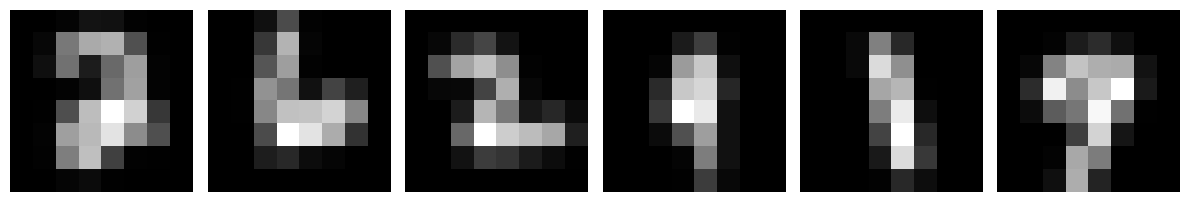

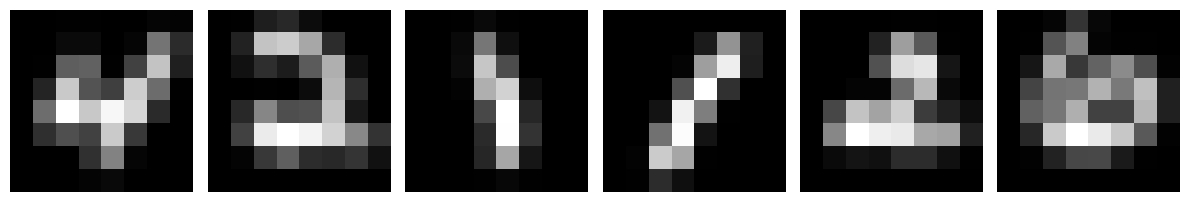

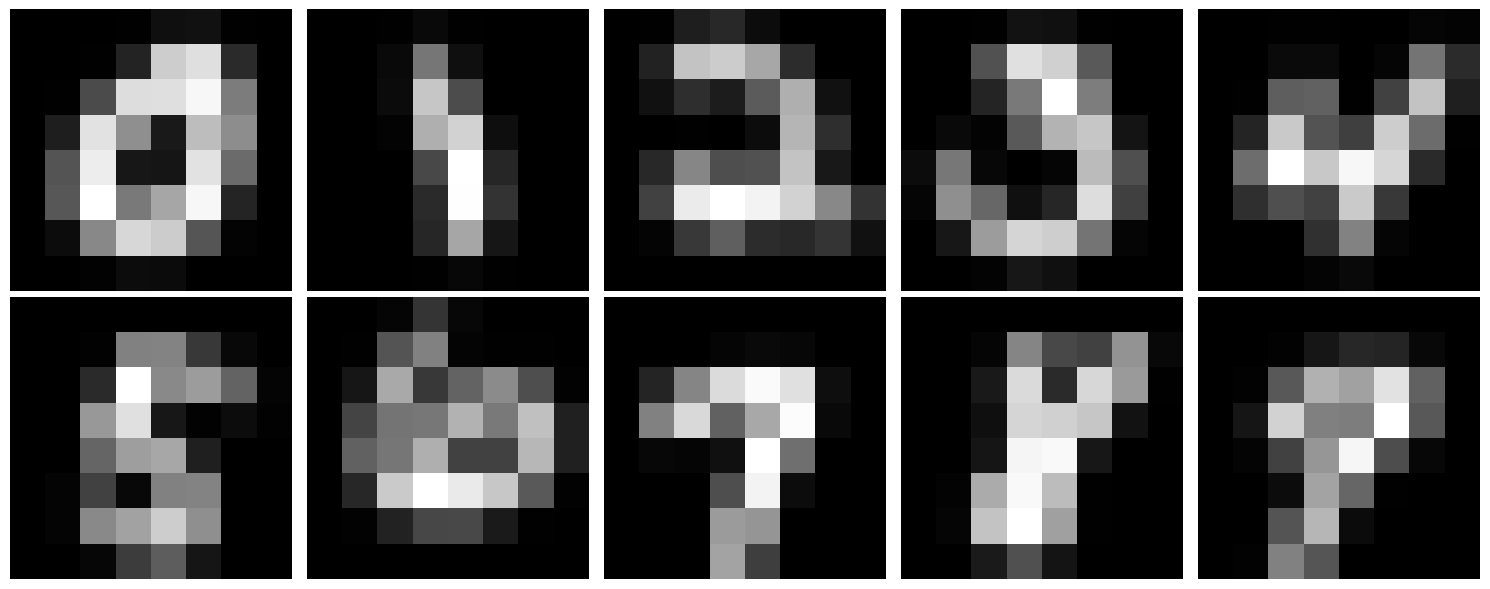

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.__len__()

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x, y = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime, y_prime = self.data[idx2]
        return (x, y), (x_prime, y_prime)
    
# create dataset and dataloader
train_pair_dataset = RandomPairDataset(data_train)
train_loader = DataLoader(train_pair_dataset, batch_size=batch_size, shuffle=True)
val_pair_dataset = RandomPairDataset(data_val)
val_loader = DataLoader(val_pair_dataset, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples, train_examples_prime = next(iter(train_loader))
train_images, train_labels = train_examples
train_images_prime, train_labels_prime = train_examples_prime
val_examples, val_examples_prime = next(iter(val_loader))
val_images, val_labels = val_examples
val_images_prime, val_labels_prime = val_examples_prime

# construct data clusters as one digit per class
val_clusters = []
for digit in range(10):
    digit_indices = (val_labels == digit).nonzero(as_tuple=True)[0]
    digit_images = val_images[digit_indices][0]
    val_clusters.append(digit_images.unsqueeze(0))

cluster_images = torch.cat(val_clusters, dim=0)
cluster_labels = torch.arange(10)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Embed data set ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
# construct convolutional neural network architecture
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # size/2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # size/4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            ResidualBlock(128),
        )
        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, latent_dim)

    def forward(self, x):
        # x: [B, 1, H, W] with arbitrary H=W=size
        x = self.conv(x)              # [B, 128, H', W']
        x = x.mean(dim=(2, 3))        # global average pooling -> [B, 128]
        x = F.relu(self.fc1(x))       # [B, 512]
        z = self.fc2(x)               # [B, latent_dim]
        return z
        
    
# instantiate the neural network
input_dim = size
hidden_dim = 20
output_dim = latent_dim  # we will embed into 2D hyperbolic space
nn_model = Encoder(output_dim)

# instantiate Gromov-Monge Embedding
T = HyperbolicGromovMongeEmbedding(nn_model, output_dim=output_dim)

In [5]:
# construct train loop
optimizer = torch.optim.Adam(T.nn_model.parameters(), lr=learning_rate_emb)
for epoch in range(num_epoch_emb):
    epoch_loss = 0.0
    for (x, y), (x_prime, y_prime) in tqdm(train_loader):
        N = x.size(0)
        optimizer.zero_grad()
        dist_data = torch.norm(x.reshape(N, -1) - x_prime.reshape(N, -1), dim=1)
        dist_emb = T.distance(x, x_prime)
        loss = torch.log((1 + dist_emb ** 2) / (1 + dist_data ** 2)).pow(2).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * N
    epoch_loss /= len(train_pair_dataset)
    print(f"Epoch {epoch+1}/{num_epoch_emb}, Loss: {epoch_loss:.6f}")


100%|██████████| 375/375 [00:18<00:00, 20.28it/s]

Epoch 1/1, Loss: 0.091932


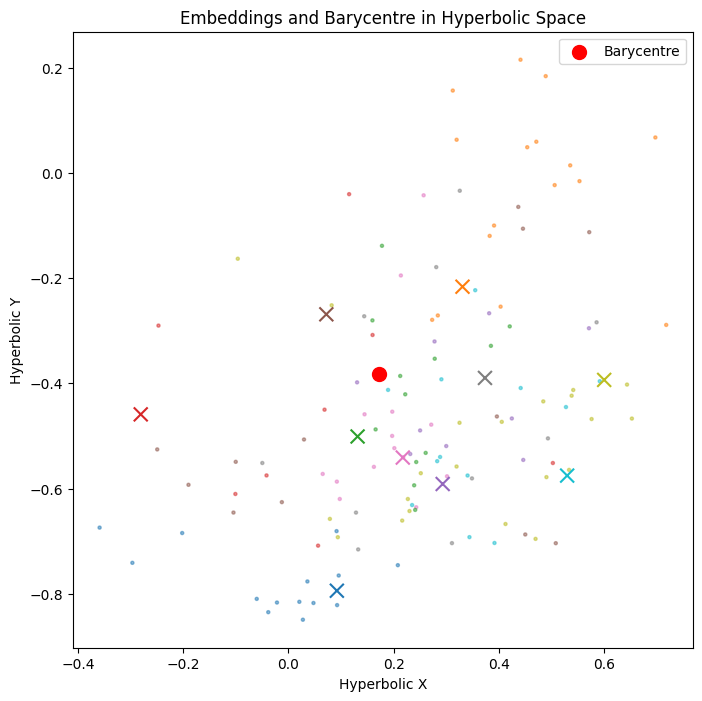

In [6]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings = T(train_images).cpu().numpy()
    cluster_embeddings = T(cluster_images).cpu().numpy()
    barycentre = T.barycentre(train_images)

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings[:, 0], train_embeddings[:, 1], c=train_labels.cpu().numpy(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings[:, 0], cluster_embeddings[:, 1], c=cluster_labels.cpu().numpy(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final.png"))
plt.show()  

In [7]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = T.distance(cluster_images[1:], cluster_images[:-1])

# update origin
T.set_origin(barycentre)

# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = T.distance(cluster_images[1:], cluster_images[:-1])

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero

Pairwise distance matrix in embedding space between cluster centers:
tensor(1.5099e-14)


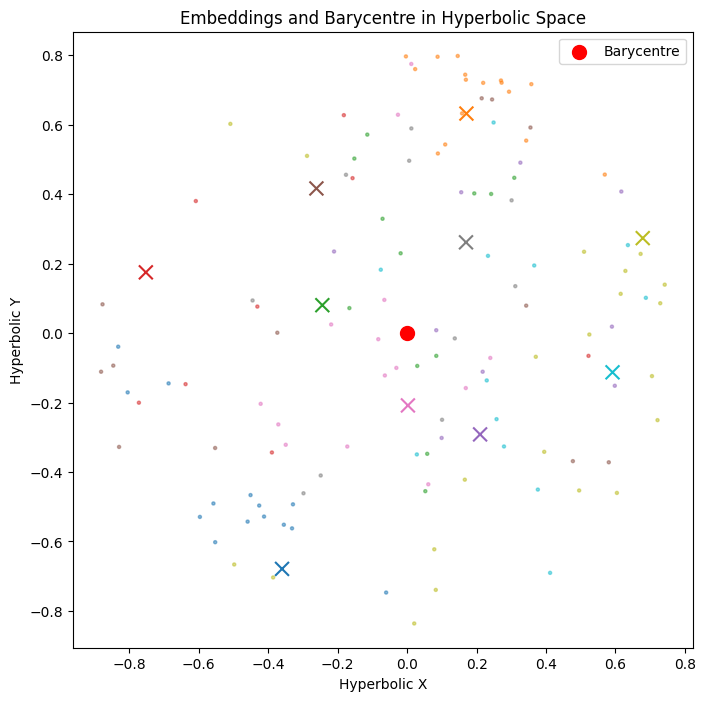

Distance between barycentres before and after centering:
3.829672220486044e-06


In [8]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings_centered = T(train_images).cpu().numpy()
    cluster_embeddings_centered = T(cluster_images).cpu().numpy()
    barycentre_centered = T.barycentre(train_images)

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings_centered[:, 0], train_embeddings_centered[:, 1], c=train_labels.cpu().numpy(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings_centered[:, 0], cluster_embeddings_centered[:, 1], c=cluster_labels.cpu().numpy(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final_centered.png"))
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = T.translate(barycentre, barycentre)
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

### Learn embedding-informed pullback geometry ###

In [9]:
# construct normalizing flow model
class SimpleNFlowImageDiffeomorphism(NFlowImageDiffeomorphism):
    def __init__(self, in_channels, height, width, kernel_size, latent_channels, order, n_flows):
        super(SimpleNFlowImageDiffeomorphism, self).__init__(in_channels, height, width, self.create_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows))

    def create_flow_model(self, in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
        base_dist = distributions.StandardNormal(shape=[in_channels, height, width])
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=in_channels))
            transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
            transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
            transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        flow_transforms = transforms.CompositeTransform(transforms_list)
        return flows.Flow(transform=flow_transforms, distribution=base_dist)

# instantiate flow model
in_channels = 1
height = size
width = size
kernel_size = 3
latent_channels = 2
n_flows = 2
order = 2
phi = SimpleNFlowImageDiffeomorphism(in_channels, height, width, kernel_size, latent_channels, order, n_flows)
    
# instantiate HGME-informed normalizing flow
reg_param = 0.01
hgme_nflow = HyperbolicGromovMongeEmbeddingInformedNFlowTraining(T, phi, reg_param=reg_param)

# freeze embedding model parameters
for param in hgme_nflow.emb.parameters():
    param.requires_grad = False

In [10]:
# construct train loop
optimizer_hgme_nflow = torch.optim.Adam(list(hgme_nflow.phi.nflow.parameters()) + [hgme_nflow.W], lr=learning_rate_flow) 
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for (x, _), _ in tqdm(train_loader):
        optimizer_hgme_nflow.zero_grad()
        loss = hgme_nflow.loss(x)
        loss.backward()
        optimizer_hgme_nflow.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(train_pair_dataset)
    print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

100%|██████████| 375/375 [00:12<00:00, 30.36it/s]

Flow Epoch 1/1, Loss: 3.512702


In [11]:
# construct manifold from learned flow
manifold = HyperbolicPullbackImageEuclidean(hgme_nflow.phi)

torch.Size([10, 1, 8, 8]) torch.Size([10, 1, 8, 8])
Reconstruction error of cluster images through learned diffeomorphism: 0.000000


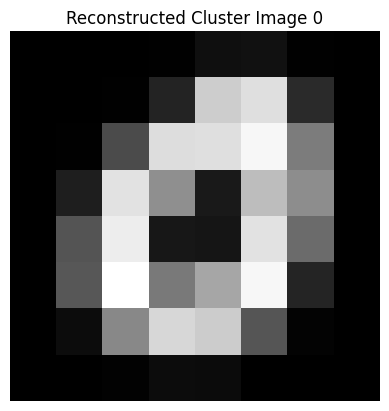

In [12]:
# debug diffeomorphism
with torch.no_grad():
    mapped_cluster_images = hgme_nflow.phi(cluster_images)
    rec_cluster_images = hgme_nflow.phi.inverse(mapped_cluster_images)

print(cluster_images.shape, rec_cluster_images.shape)

# print reconstruction error
reconstruction_error = torch.norm((cluster_images - rec_cluster_images).reshape(10,-1), dim=1).mean().item()
print(f"Reconstruction error of cluster images through learned diffeomorphism: {reconstruction_error:.6f}")

plt.imshow(rec_cluster_images[0].squeeze().cpu(), cmap='gray')
plt.title("Reconstructed Cluster Image 0")
plt.axis('off')
plt.show()

torch.Size([5, 8, 8])


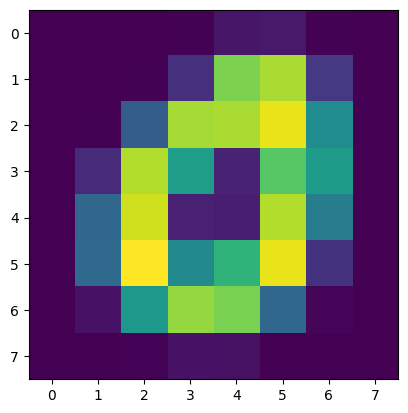

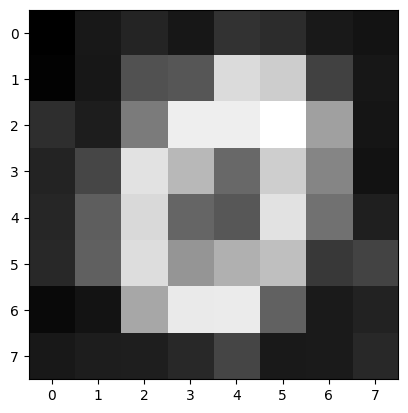

In [13]:
# debug geodesics between cluster 0 and 1
K = 5
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    geodesics = manifold.geodesic(cluster_images[0][None,None], cluster_images[1][None,None], t)[0,0,0,:,0]

print(geodesics.shape)

plt.imshow(cluster_images[0,0])
plt.show()
plt.imshow(geodesics[0].cpu(), cmap='gray')
plt.show()


Max difference between geodesic endpoints and original images: 2.5579138011473797


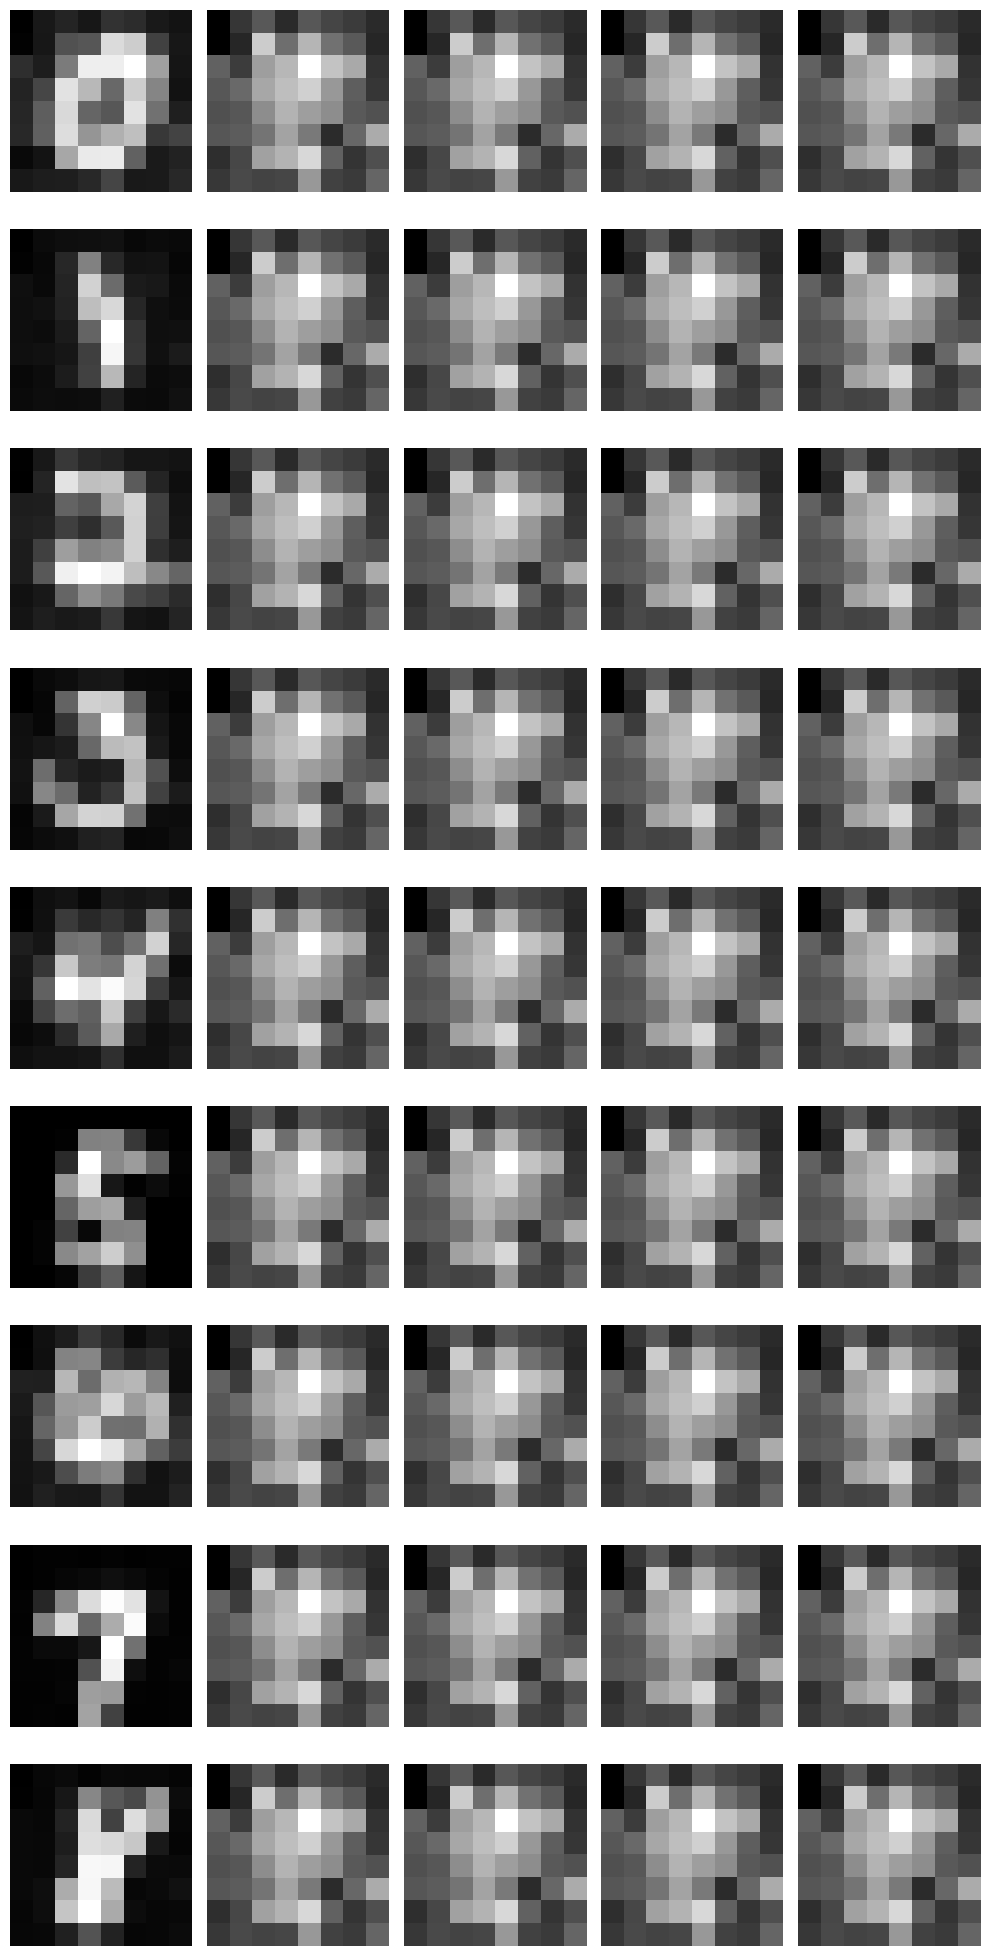

In [14]:
# compute geodesics between all pairs of points
K = 5
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    geodesics = manifold.geodesic(cluster_images[None], cluster_images[None], t)


# plot difference between geodesic endpoints and original images
endpoint_diff = torch.norm((geodesics[0, :, 0, 0] - cluster_images).reshape(10, -1), dim=1)
print("Max difference between geodesic endpoints and original images:", endpoint_diff.max().item())

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(geodesics[0, i, i+1, k, 0], cmap='gray')
        # axes[i*K + k].imshow(val_images[0].squeeze(), cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()

In [15]:
# sanity check: is the embedding still the same (and was not accidentally changed during flow training)
with torch.no_grad():
    embeddings_after_flow = hgme_nflow.emb(data)
print("Max difference in embeddings before and after flow training:", (embeddings_after_flow - embeddings_centered).abs().max().item())  # should be close to zero

NameError: name 'data' is not defined

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


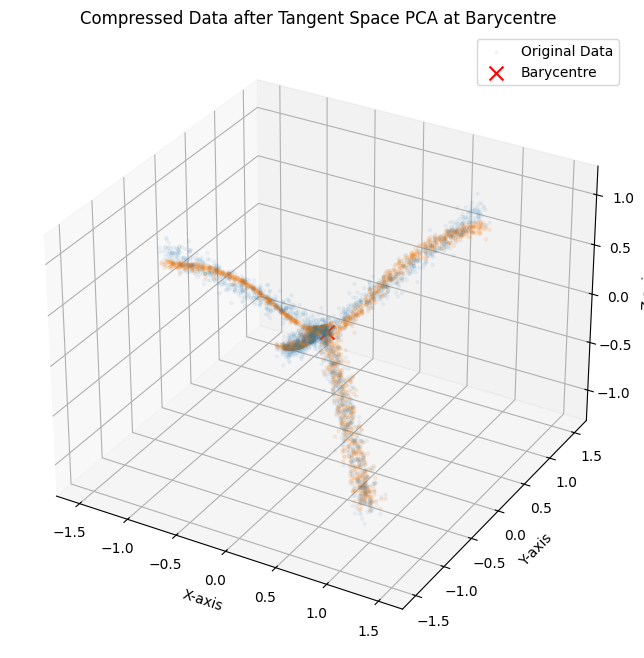

Mean reconstruction error after RAE compression: 0.07326821982860565


In [ ]:
# compute data barycentre
barycentre_data = manifold.barycentre(data, tol=1e-5, max_iter=100, step_size=0.5, red_coef=None)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_bary = l2TangentSpacePCAVectorSolver(data, manifold, barycentre_data)
# compute principal directions
_, compressed_data, _ = l2_pga_solver_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(compressed_data[:, 0].numpy(), compressed_data[:, 1].numpy(), compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Compressed Data after Tangent Space PCA at Barycentre")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"data_compressed.png"))
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after RAE compression:", rel_error)

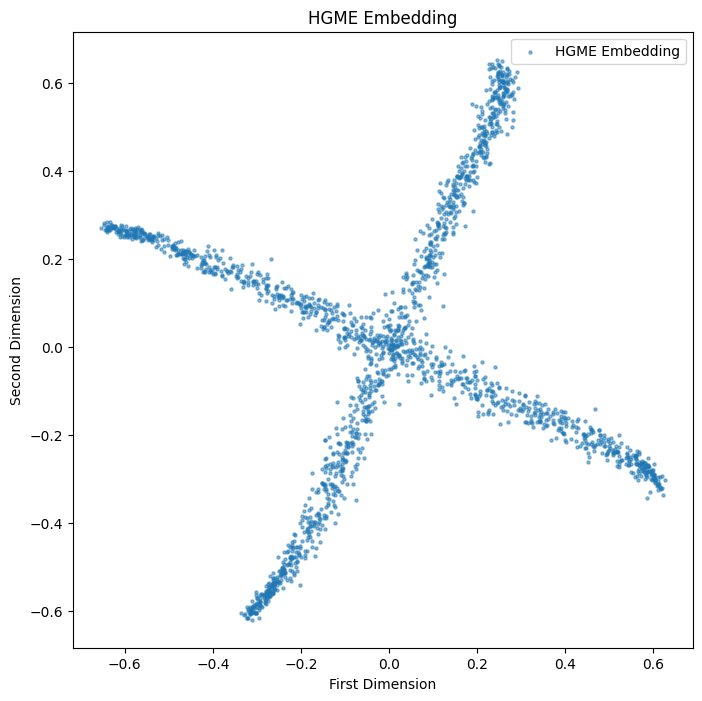

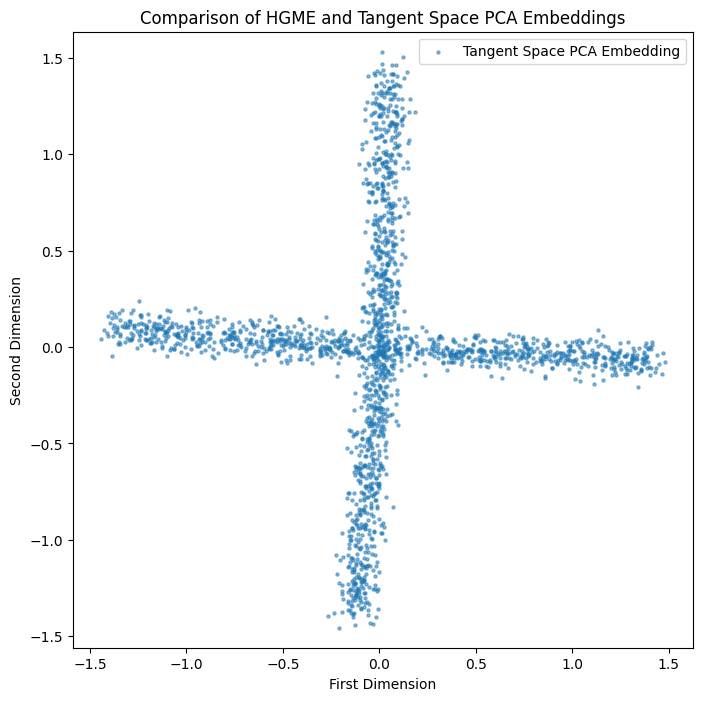

In [ ]:
# compare embeddings
pca_embedding = l2_pga_solver_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.title("HGME Embedding")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(pca_embedding[:, 0], pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.title("Comparison of HGME and Tangent Space PCA Embeddings")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.savefig(os.path.join(results_folder,"emb_comparison.png"))
plt.show()

Tangent basis vectors at barycentre:
tensor([[-0.7476, -0.6625, -0.0468],
        [-0.6633,  0.7483,  0.0032]])
Inner products between tangent basis vectors (should be close to identity):
tensor([[1.0000e+00, 8.9911e-08],
        [8.9911e-08, 1.0000e+00]])


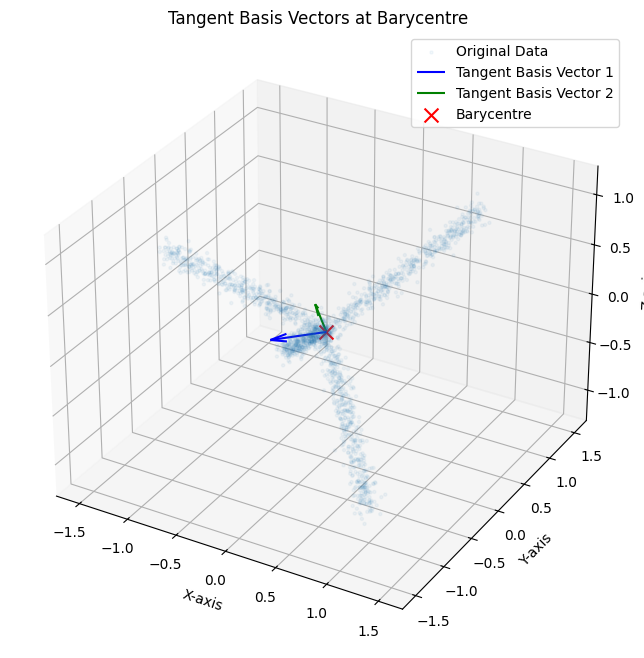

In [ ]:
# get tangent basis
tangent_basis_barycentre_data = l2_pga_solver_bary.get_tangent_basis(2)
print("Tangent basis vectors at barycentre:")
print(tangent_basis_barycentre_data)
# make sure they are orthonormal
print("Inner products between tangent basis vectors (should be close to identity):")
print(tangent_basis_barycentre_data @ tangent_basis_barycentre_data.t())

# plot tangent basis vectors at barycentre in 3D with data points
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')  
# plot tangent basis vectors through quiver plot
ax.quiver(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(),
          tangent_basis_barycentre_data[0, 0].item(), tangent_basis_barycentre_data[0, 1].item(), tangent_basis_barycentre_data[0, 2].item(),
          length=0.5, color='blue', label='Tangent Basis Vector 1')
ax.quiver(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(),
          tangent_basis_barycentre_data[1, 0].item(), tangent_basis_barycentre_data[1, 1].item(), tangent_basis_barycentre_data[1, 2].item(),
          length=0.5, color='green', label='Tangent Basis Vector 2')    
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Tangent Basis Vectors at Barycentre")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
plt.legend()
plt.show()

In [ ]:
# construct RAE
s_rae = StandardVectorRiemannianAutoencoder(manifold, barycentre_data, tangent_basis_barycentre_data)
k_rae = KfoldVectorRiemannianAutoencoder(manifold, barycentre_data, tangent_basis_barycentre_data, K=5)

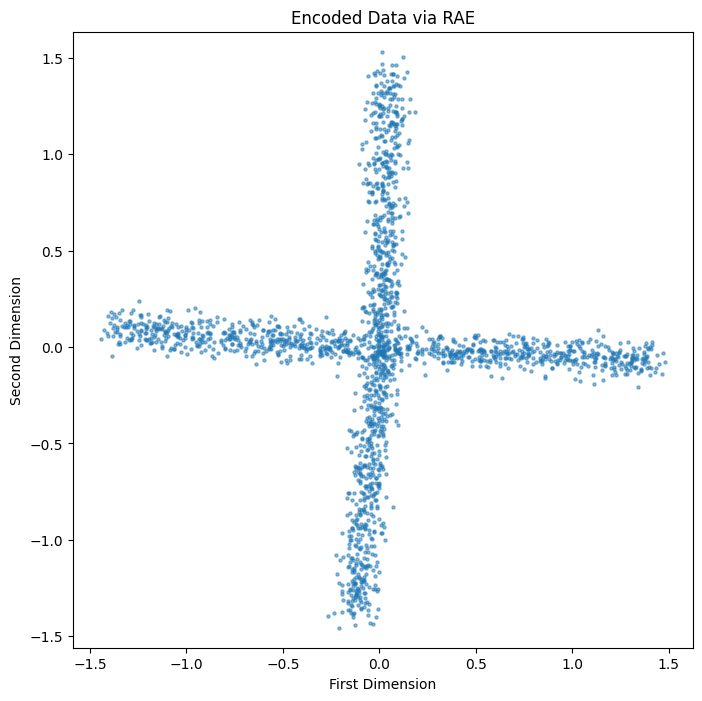

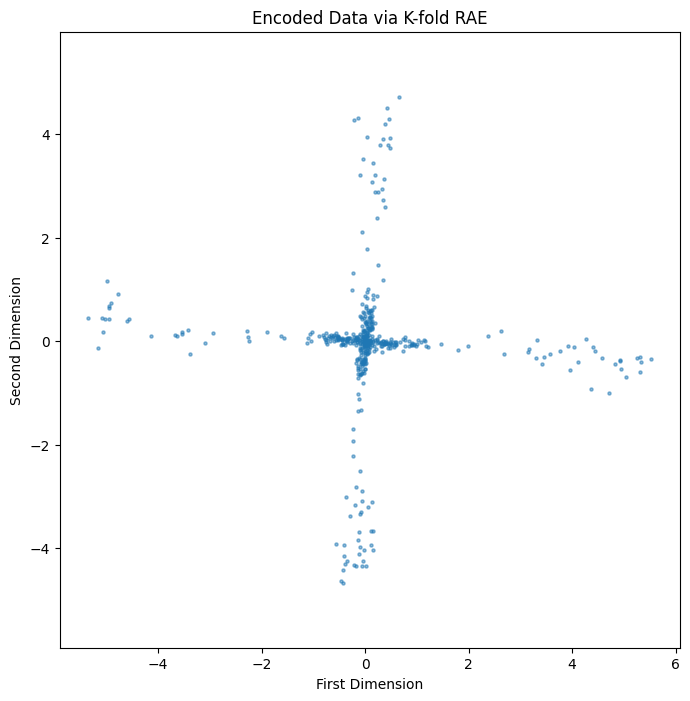

In [ ]:
# encode data
with torch.no_grad():
    s_rae_encoded_data = s_rae.encode(data)
    k_rae_encoded_data = k_rae.encode(data)

# plot encoded data
plt.figure(figsize=(8, 8))
plt.scatter(s_rae_encoded_data[:, 0].numpy(), s_rae_encoded_data[:, 1].numpy(), s=5, alpha=0.5)
plt.title("Encoded Data via RAE")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(k_rae_encoded_data[:, 0].numpy(), k_rae_encoded_data[:, 1].numpy(), s=5, alpha=0.5)
plt.title("Encoded Data via K-fold RAE")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.show()

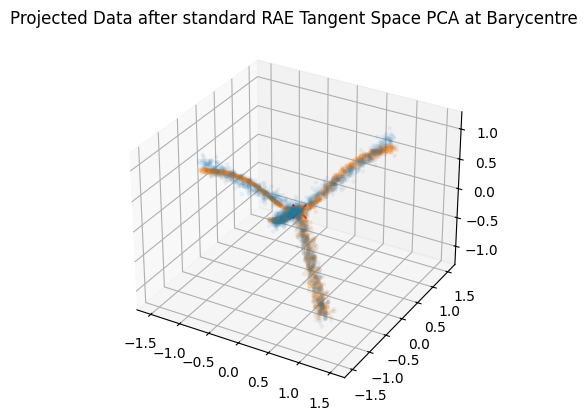

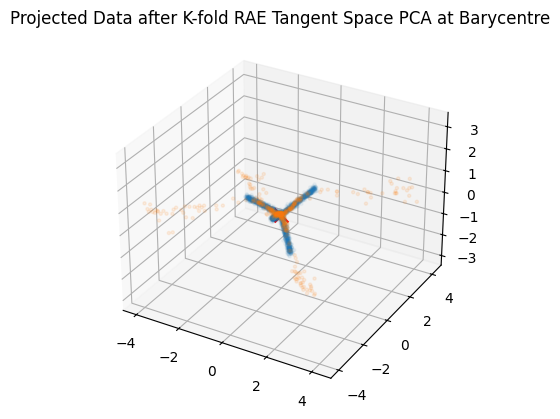

Mean reconstruction error after RAE compression: 0.07326658815145493
Mean reconstruction error after K-fold RAE compression: nan


In [ ]:
# project data
with torch.no_grad():
    s_rae_projected_data = s_rae.project_on_manifold(data)
    k_rae_projected_data = k_rae.project_on_manifold(data)

# plot compressed data in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(s_rae_projected_data[:, 0].numpy(), s_rae_projected_data[:, 1].numpy(), s_rae_projected_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Projected Data after standard RAE Tangent Space PCA at Barycentre")
plt.axis('equal')
plt.show()

plt.figure()
ax = plt.axes(projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(k_rae_projected_data[:, 0].numpy(), k_rae_projected_data[:, 1].numpy(), k_rae_projected_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Projected Data after K-fold RAE Tangent Space PCA at Barycentre")
plt.axis('equal')
plt.show()

# compute error between original data and compressed data
rel_error_s_rae_projected = (torch.norm(data - s_rae_projected_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
rel_error_k_rae_projected = (torch.norm(data - k_rae_projected_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after RAE compression:", rel_error_s_rae_projected)
print("Mean reconstruction error after K-fold RAE compression:", rel_error_k_rae_projected)